In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [5]:
df = pd.read_csv(r"D:\downloads\consumer_electronics_sales_data.csv") 
df
######## Here I used this data to complete my project with it, where I find a data that suits objectives of the company and complete with in machine learning algorithms and EDA ######
######## And because its cleaned i have shown my skills in data cleaning using out source uncleaned data #######

,ProductID,ProductCategory,ProductBrand,ProductPrice,CustomerAge,CustomerGender,PurchaseFrequency,CustomerSatisfaction,PurchaseIntent
0,5874,Smartphones,Other Brands,312.949668,18,0,2,1,0
1,5875,Smart Watches,Samsung,980.389404,35,1,7,2,1
2,5876,Tablets,Samsung,2606.718293,63,0,1,5,1
3,5877,Smartphones,Samsung,870.395450,63,1,10,3,1
4,5878,Tablets,Sony,1798.955875,57,0,17,3,0
...,...,...,...,...,...,...,...,...,...
8995,14869,Smart Watches,Samsung,1041.149163,36,1,16,4,0
8996,14870,Smartphones,Samsung,1485.694311,57,0,5,1,1
8997,14871,Headphones,Samsung,2887.369597,28,0,18,4,0
8998,14872,Tablets,HP,1490.453964,38,0,4,2,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductID             9000 non-null   int64  
 1   ProductCategory       9000 non-null   object 
 2   ProductBrand          9000 non-null   object 
 3   ProductPrice          9000 non-null   float64
 4   CustomerAge           9000 non-null   int64  
 5   CustomerGender        9000 non-null   int64  
 6   PurchaseFrequency     9000 non-null   int64  
 7   CustomerSatisfaction  9000 non-null   int64  
 8   PurchaseIntent        9000 non-null   int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 632.9+ KB


In [7]:
df.describe()

,ProductID,ProductPrice,CustomerAge,CustomerGender,PurchaseFrequency,CustomerSatisfaction,PurchaseIntent
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,10373.500000,1527.429195,43.347000,0.508889,10.054667,2.996000,0.566444
std,2598.220545,829.900898,15.055084,0.499949,5.461328,1.405301,0.495593
min,5874.000000,100.376358,18.000000,0.000000,1.000000,1.000000,0.000000
25%,8123.750000,809.165014,30.000000,0.000000,5.000000,2.000000,0.000000
50%,10373.500000,1513.024577,43.000000,1.000000,10.000000,3.000000,1.000000
75%,12623.250000,2244.415520,56.000000,1.000000,15.000000,4.000000,1.000000
max,14873.000000,2999.852253,69.000000,1.000000,19.000000,5.000000,1.000000


In [8]:
desc = df.describe()
desc.loc["count"] = desc.loc["count"].apply(lambda x: f"{int(x)}")
desc.columns.to_list()
desc = desc.drop('ProductID', axis=1)
desc

C:\Users\oasm2\AppData\Local\Temp\ipykernel_23628\1293875028.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9000' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  desc.loc["count"] = desc.loc["count"].apply(lambda x: f"{int(x)}")
C:\Users\oasm2\AppData\Local\Temp\ipykernel_23628\1293875028.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9000' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  desc.loc["count"] = desc.loc["count"].apply(lambda x: f"{int(x)}")
C:\Users\oasm2\AppData\Local\Temp\ipykernel_23628\1293875028.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9000' has dtype incompatible with float64, please explicitly cast to a compatible dt

,ProductPrice,CustomerAge,CustomerGender,PurchaseFrequency,CustomerSatisfaction,PurchaseIntent
count,9000,9000,9000,9000,9000,9000
mean,1527.429195,43.347,0.508889,10.054667,2.996,0.566444
std,829.900898,15.055084,0.499949,5.461328,1.405301,0.495593
min,100.376358,18.0,0.0,1.0,1.0,0.0
25%,809.165014,30.0,0.0,5.0,2.0,0.0
50%,1513.024577,43.0,1.0,10.0,3.0,1.0
75%,2244.41552,56.0,1.0,15.0,4.0,1.0
max,2999.852253,69.0,1.0,19.0,5.0,1.0


PHASE 1 : DATA QUALITY

In [9]:
df.isnull().sum()

ProductID               0
ProductCategory         0
ProductBrand            0
ProductPrice            0
CustomerAge             0
CustomerGender          0
PurchaseFrequency       0
CustomerSatisfaction    0
PurchaseIntent          0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["CustomerGender"].unique()

array([0, 1])

#### PHASE 2 : UNIVARIATE DATA ANALYSIS SECTION

#### 1- DEAL WITH NUMERIC COLUMNS

(array([1, 2, 3, 4, 5, 6]),
 [Text(1, 0, 'ProductPrice'),
  Text(2, 0, 'CustomerAge'),
  Text(3, 0, 'CustomerGender'),
  Text(4, 0, 'PurchaseFrequency'),
  Text(5, 0, 'CustomerSatisfaction'),
  Text(6, 0, 'PurchaseIntent')])

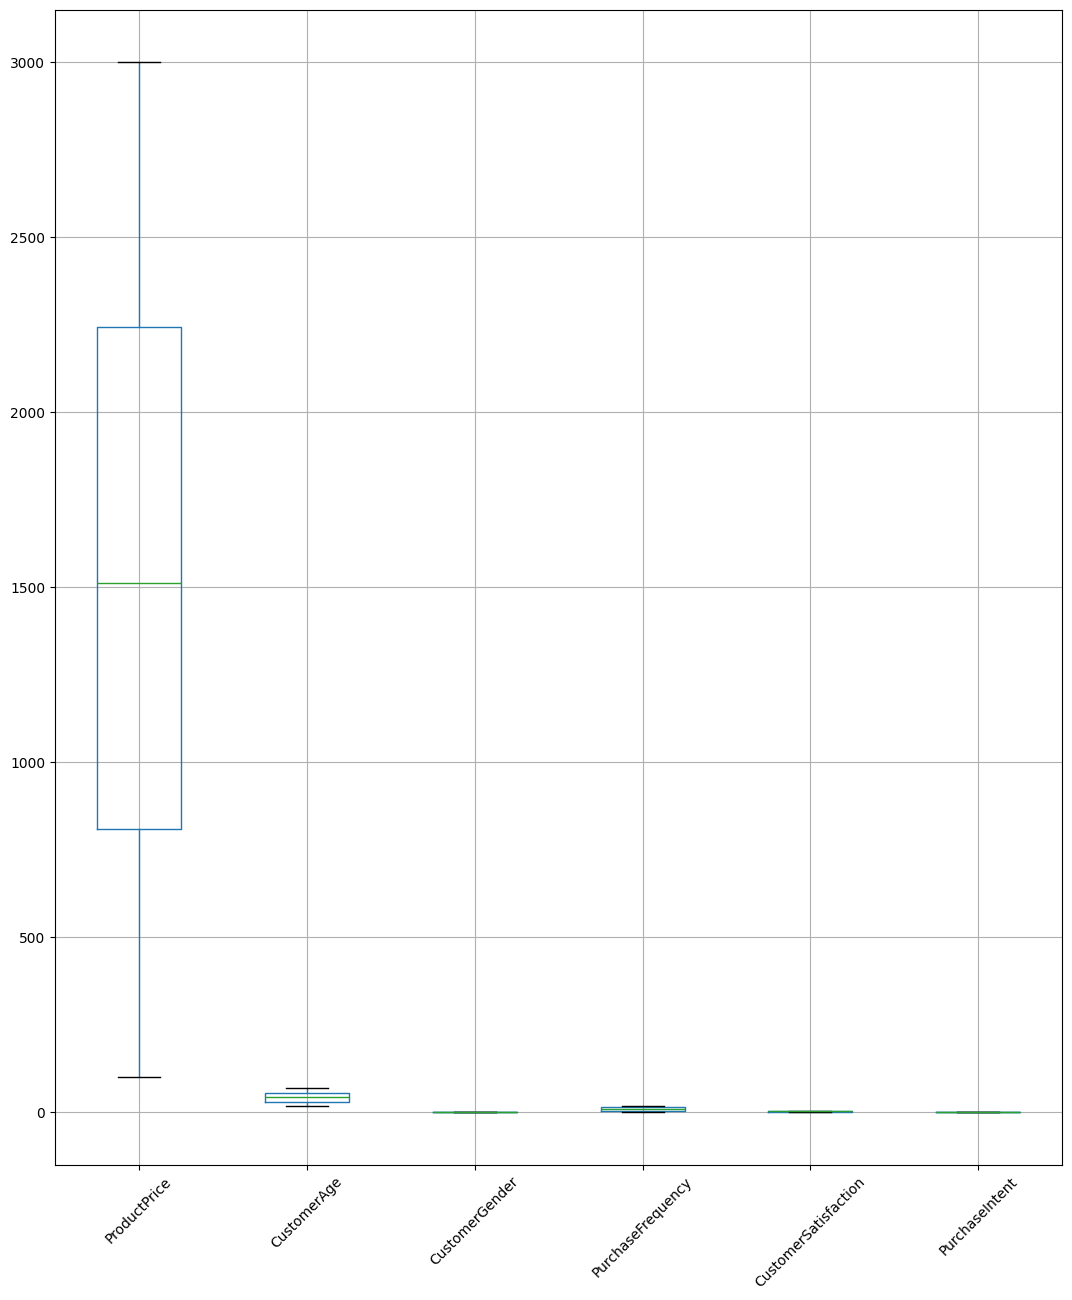

In [12]:
without_ID_column = df.drop("ProductID", axis=1)
without_ID_column.boxplot(figsize=(13,15))
plt.xticks(rotation= 45)
##### Here we see that Product Price has no outliers faraway from the 75th percentile and 25th Percentile or third and first quartile which tell us that there is no prices faraway from range and it can't destory the linear model in ML model because of this extreme values #####

### a- NEED TO CHECK THE OUTLIER BY NUMBERS TO DOUBLE CHEKING

In [ ]:
Q1 = without_ID_column['ProductPrice'].quantile(0.25)
Q3 = without_ID_column['ProductPrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = without_ID_column[(without_ID_column['ProductPrice'] < lower_bound) | (without_ID_column['ProductPrice'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")
print(outliers[['ProductPrice']].describe())
##### NOTE: Here confirmed that there is no outliers in the price column #####

Number of outliers: 0
       ProductPrice
count           0.0
mean            NaN
std             NaN
min             NaN
25%             NaN
50%             NaN
75%             NaN
max             NaN


In [ ]:
Q1 = without_ID_column["ProductPrice"].quantile(0.25)
Q2 = without_ID_column["ProductPrice"].quantile(0.75)
IQR = Q2 - Q1
lower_bound = Q1 -1.5*IQR
upper_bound = Q2 + 1.5*IQR
outliers = [without_ID_column["ProductPrice"]<lower_bound | without_ID_column["ProductPrice"]>upper_bound]
print(f"no.of outliers: {len(outliers)}")
print(outliers[["ProductPrice"]].describe())


# 2- Categorical Columns

# 3- HISTOGRAMS + SKEWNEES


In [51]:
without_ID_column.skew(numeric_only=True).round(5)

ProductPrice            0.02908
CustomerAge             0.00352
CustomerGender         -0.03557
PurchaseFrequency      -0.00147
CustomerSatisfaction    0.00470
PurchaseIntent         -0.26820
dtype: float64

ProductPrice skew: 0.029


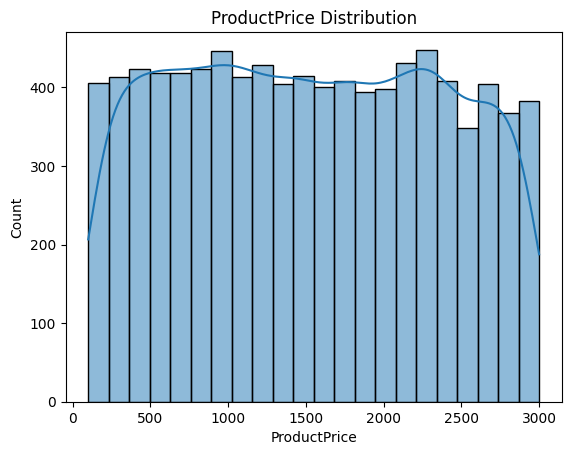

CustomerAge skew: 0.004


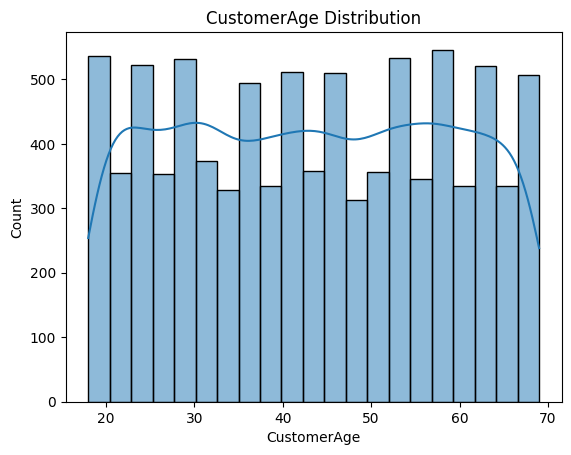

PurchaseFrequency skew: -0.001


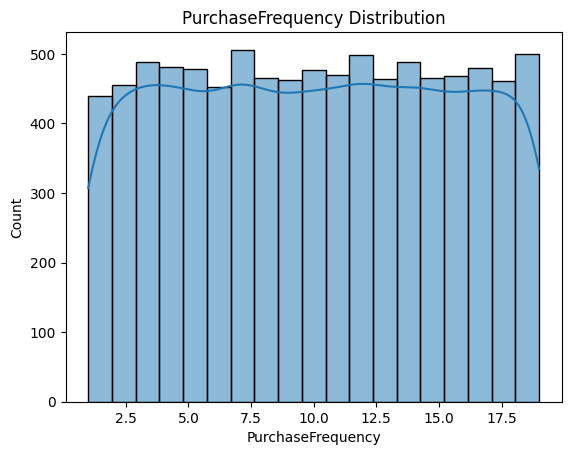

In [ ]:
for col in ['ProductPrice', 'CustomerAge', 'PurchaseFrequency']:
    print(f"{col} skew: {without_ID_column[col].skew():.3f}")
    sns.histplot(without_ID_column[col], kde=True)
    plt.title(f'{col} Distribution')
    plt.show()
    ##### NOTE: Here we can see that the distribution of Product Price is nearly symmetric and Customer Age is nearly symmetric and Purchase Frequency is flat where its binary just 0 and 1 ####

# TARGET VARIABLE ANALYSIS

# 1-Here we see that PURCHASE INTENT COULD HAS FAVORTISM TO BE DECODED TO BE (1) NOT (0)
# COULD harm the ML model to disqualify the not intent to purshace automatically

In [ ]:
without_ID_column["PurchaseIntent"].value_counts(normalize=True)*100
### NOTE: Here we can see that the Purchase Intent is 0 and 1 where 1 is 56% and 0 is 43% which tell us that the data is balanced and it will not affect the model in ML model ####

PurchaseIntent
1    56.644444
0    43.355556
Name: proportion, dtype: float64

## (Does this feature's value genuinely differ between people who have purchase intent and people who don't?) 

## THATS THE QUESTION THAT THROUGH THE TESTS TO EACH COLUMN TO PURCHASE INTENT COLUMN WILL SEE WHICH COLUMNS ARE GOOD CANDIDATE TO BE PREDICTOR VARIABLES IN NEXT STAGE (ML MODEL)

# A- Bivariate Data analysis
# 1- Correlation Heatmap to see realtionships

In [ ]:
df.corr(numeric_only= True).drop(index ="ProductID", columns= "ProductID")
## Note: Here we can see that there is no correlation between (Consumer Satifaction) and (Product Price); (Product price) and (Customer Gender) ##


,ProductPrice,CustomerAge,CustomerGender,PurchaseFrequency,CustomerSatisfaction,PurchaseIntent
ProductPrice,1.000000,-0.009322,0.001835,0.009281,0.002112,-0.017512
CustomerAge,-0.009322,1.000000,-0.010767,0.005746,0.003753,0.289798
CustomerGender,0.001835,-0.010767,1.000000,-0.008643,0.007959,0.504412
PurchaseFrequency,0.009281,0.005746,-0.008643,1.000000,0.020603,-0.001465
CustomerSatisfaction,0.002112,0.003753,0.007959,0.020603,1.000000,0.391133
PurchaseIntent,-0.017512,0.289798,0.504412,-0.001465,0.391133,1.000000


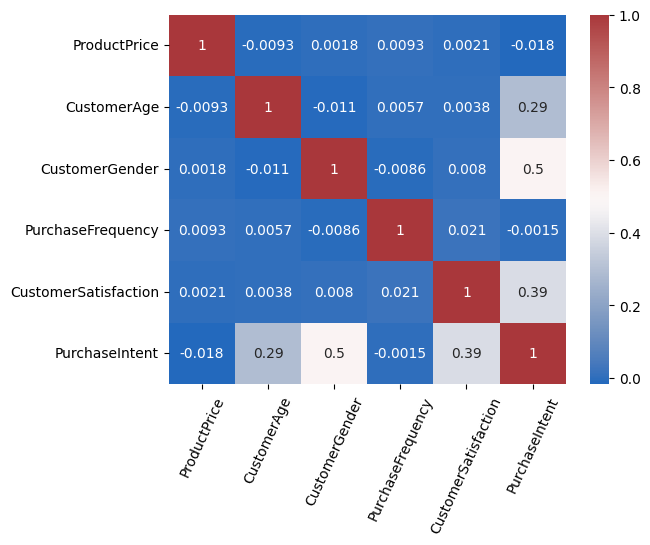

In [31]:
sns.heatmap(without_ID_column.corr(numeric_only=True), annot=True,  cmap="vlag")
plt.Figure(figsize=(10,8))
plt.xticks(rotation= 65)
plt.show()

# 2- Pair plot many scatter plots 

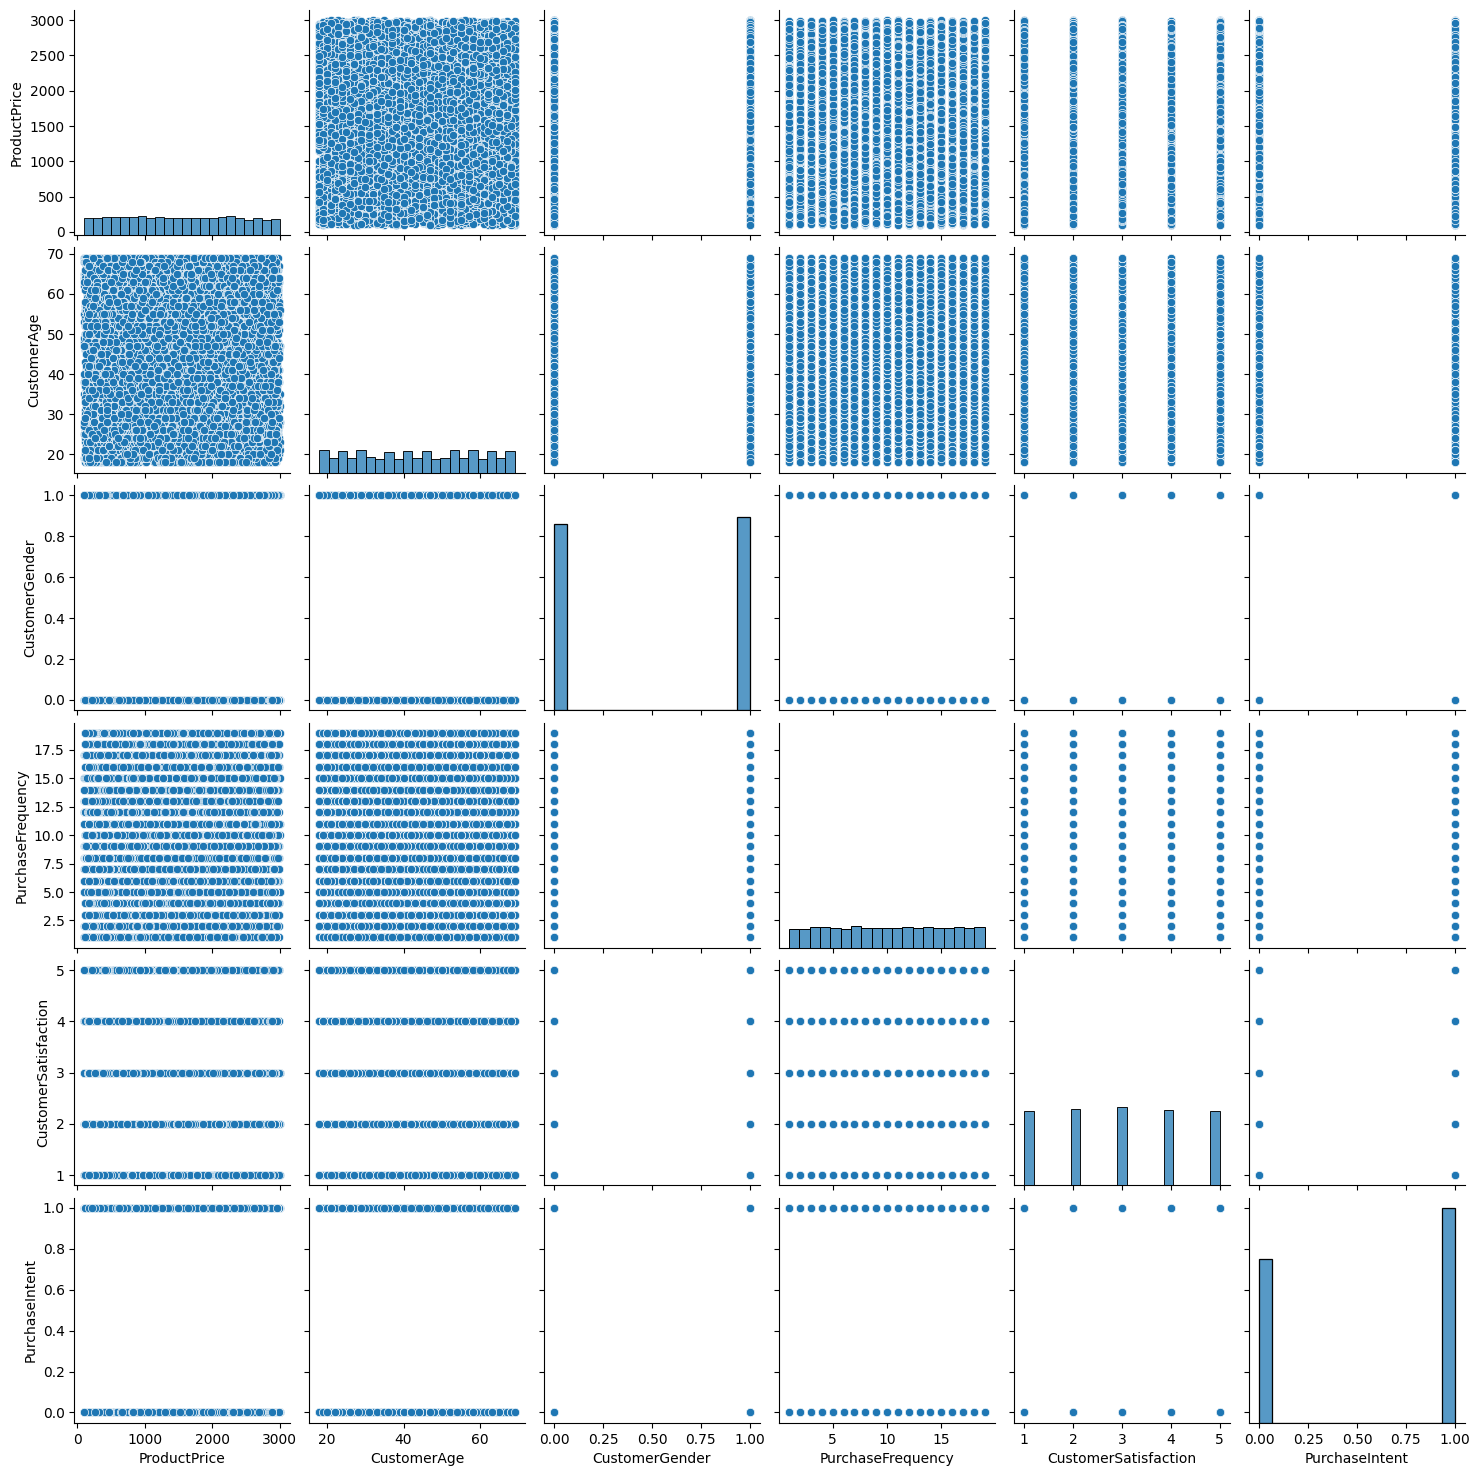

In [ ]:
sns.pairplot(without_ID_column)
plt.show()
### ## NOTE: Here we can see that there is no correlation between (Purchase Frequency) and (Product Price); (Product price) and (Customer Age) 

## 3- T-test results to Numeric columns

In [ ]:
from scipy.stats import ttest_ind

numeric_cols = ['ProductPrice', 'CustomerAge', 'PurchaseFrequency', 'CustomerSatisfaction']

for col in numeric_cols:
    group0 = without_ID_column[without_ID_column['PurchaseIntent'] == 0][col]
    group1 = without_ID_column[without_ID_column['PurchaseIntent'] == 1][col]
    t_stat, p_val = ttest_ind(group0, group1)
    print(f"{col}: t = {t_stat:.3f}, p = {p_val:.4f}")
## Here we can see that the p-value for Customer satisfaction and CustomerAge is strongly significant through t-test and P-value which means that there is a significant difference between the two groups (PurchaseIntent = 0 and PurchaseIntent = 1) for these two variables. However, the p-value for PurchaseFrequency and ProductPrice is weakly significant which means that there is no significant difference between the two groups for these two variables.
## which can say that the Customer satisfaction and CustomerAge are important factors that affect the PurchaseIntent of customers, while PurchaseFrequency and ProductPrice are not as important.


ProductPrice: t = 1.661, p = 0.0967
CustomerAge: t = -28.722, p = 0.0000
PurchaseFrequency: t = 0.139, p = 0.8895
CustomerSatisfaction: t = -40.314, p = 0.0000


# 4- CHI-square test fro categorical columns to intent column

In [ ]:
from scipy.stats import chi2_contingency

categorical_cols = ['ProductCategory', 'ProductBrand', 'CustomerGender']

for col in categorical_cols:
    contingency = pd.crosstab(without_ID_column[col], without_ID_column['PurchaseIntent'])
    chi2, p_val, dof, expected = chi2_contingency(contingency)
    print(f"{col}: chi2 = {chi2:.3f}, p = {p_val:.4f}")
# 

ProductCategory: chi2 = 6.932, p = 0.1395
ProductBrand: chi2 = 7.259, p = 0.1228
CustomerGender: chi2 = 2287.851, p = 0.0000


# 5-Categorical Relationships

In [38]:
pd.crosstab(df['ProductCategory'], df['ProductBrand'])

ProductBrand,Apple,HP,Other Brands,Samsung,Sony
ProductCategory,,,,,
Headphones,346,348,359,341,344
Laptops,359,381,363,391,348
Smart Watches,340,365,356,379,370
Smartphones,343,372,362,387,377
Tablets,372,354,336,356,351


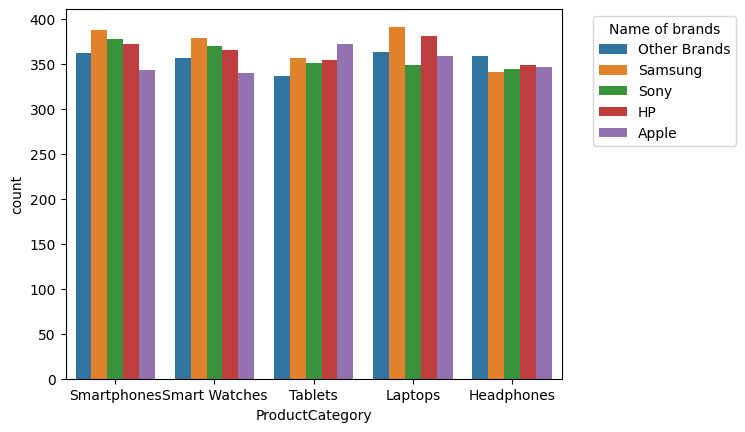

In [45]:
sns.countplot(x='ProductCategory', hue='ProductBrand', data=df)
plt.legend(title= "Name of brands", bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()
#### NOTE: samsung most sales in smartphones and watches products and Laptops while apple in Tablets ####

In [ ]:
top500 = df.sort_values(by="CustomerSatisfaction", ascending=False).head(500)
top500["ProductBrand"].value_counts()
##From this type of analysis I have found that major customer satisfaction comes from buying "Sony" products which can see that it could be a minor proof that company could increase sellings## 

ProductBrand
Sony            106
Other Brands    103
HP               98
Apple            97
Samsung          96
Name: count, dtype: int64

In [ ]:
without_ID_column = df.drop("ProductID", axis=1)
to_draw = without_ID_column.groupby('ProductCategory')['CustomerAge'].mean().sort_values(ascending=True)
### Here we see that the most Age who pruchase these products are early 40's means we can use our advertisments that fits fir this age ####

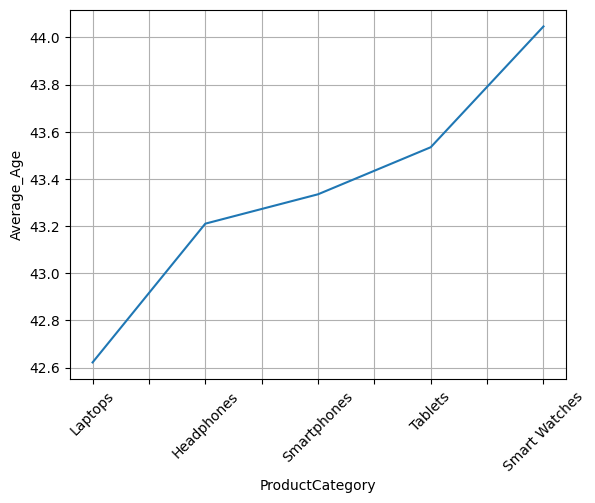

In [ ]:
to_draw.plot()
plt.Figure(figsize=(30,4))
plt.xticks(rotation=45)
plt.ylabel("Average_Age")
plt.tight_layout
plt.grid()
plt.show()

In [ ]:
to_draw2 = without_ID_column.groupby('ProductCategory').mean(numeric_only=True).sort_values(by="ProductCategory",ascending=True)
to_draw2

,ProductPrice,CustomerAge,CustomerGender,PurchaseFrequency,CustomerSatisfaction,PurchaseIntent
ProductCategory,,,,,,
Headphones,1567.213353,43.210012,0.511507,10.358458,2.999425,0.559839
Laptops,1522.446441,42.621607,0.486428,10.098806,2.995114,0.547231
Smart Watches,1538.932367,44.046409,0.523757,9.896133,3.001657,0.581215
Smartphones,1479.300697,43.334601,0.514938,9.991309,2.997284,0.582835
Tablets,1531.848182,43.534200,0.508197,9.938383,2.986433,0.560769
